## Assignment-1
| Name          | Roll Number |
|---------------|-------------|
| Anushk Kumar  | 2023115     |
| Arhan Jain    | 2023118     |


Importing all the required Libraries
```bash
numpy
sklearn
```

In [2]:
import sklearn as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib

## Question 1

In [3]:
import random
import hashlib
import pandas as pd

In [21]:
class Hash_Table:
    def __init__(self, m = 1, hashing = "default", p = 524287, a = random.randint(1, 524286)):
        if (hashing == "default"):
            self.hash_list = [[] for i in range(m)]
            self.p = p
            self.m = m
            self.a = a
        else:
            self.hash_dict = {}
            self.m = m
        
    def universal_hash_function(self, X):
        h_x = ((self.a * X) % self.p) % self.m
        self.insert_uni(h_x, X)
        return h_x
    
    def insert_uni(self, hash, X):
        self.hash_list[hash].append(X)
        
    def hash_md5_string(string):
        has = hashlib.sha256(string.encode('utf-8')).hexdigest()
        dec_from_hex = {'0':0, '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7':7, '8':8, '9':9, 'a':10, 'b':11, 'c':12, 'd':13, 'e':14, 'f':15}
        to_dec = dec_from_hex[has[-4]]*16**3 + dec_from_hex[has[-3]]*16**2 + dec_from_hex[has[-2]]*16 + dec_from_hex[has[-1]]
        return to_dec

    def random_hash_function(self, X):
        h_x = int(self.m * random.random())
        self.insert_rand(h_x, X)
        return h_x
    
    def insert_rand(self, hash, X):
        if hash in self.hash_dict.keys():
            self.hash_dict[hash].append(X)
        else:
            self.hash_dict[hash] = [X]

In [22]:
hash_table = Hash_Table(m=10000)
hash_table.universal_hash_function(123456789)
print(hash_table.hash_list)

[[], [], [], [123456789], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []

In [23]:
df = pd.DataFrame(columns = ['String', 'HashVal'])
words = []
with open('words.txt', 'r') as f:
    words = f.readlines()

word_hash = []
has_vals = []

for w in words:
    temp = w
    if (w[-1] == '\n'):
        temp = w[:-1]
    word_hash.extend([temp])
    has_vals.extend([Hash_Table.hash_md5_string(temp)])

df['String'] = word_hash
df['HashVal'] = has_vals
df.to_csv('hash_values.csv', index = False)

In [24]:
# Q1 c)
m = 500000
uni = Hash_Table(m)
ran = Hash_Table(m, hashing = "random")

results = {"Universal Hashing": [], "Random Hashing": []}

for i in range(5):
    for j in range(1, m+1):
        uni.universal_hash_function(j)
        ran.random_hash_function(j)
    results["Universal Hashing"].append({'Max' : 0, 'Min' : m})
    for j in uni.hash_list:
        if (len(j) > results["Universal Hashing"][-1]['Max']):
            results["Universal Hashing"][-1]['Max'] = len(j)
        if (len(j) < results["Universal Hashing"][-1]['Min']):
            results["Universal Hashing"][-1]['Min'] = len(j)
            
    results["Random Hashing"].append({'Max' : 0, 'Min' : m})
    for key in ran.hash_dict.keys():
        l = len(ran.hash_dict[key])
        if (l > results["Random Hashing"][-1]['Max']):
            results["Random Hashing"][-1]['Max'] = l
        if (l < results["Random Hashing"][-1]['Min']):
            results["Random Hashing"][-1]['Min'] = l
    
    uni = Hash_Table(m)
    ran = Hash_Table(m, hashing = "random")
    
print(results)

{'Universal Hashing': [{'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}], 'Random Hashing': [{'Max': 8, 'Min': 1}, {'Max': 10, 'Min': 1}, {'Max': 9, 'Min': 1}, {'Max': 8, 'Min': 1}, {'Max': 9, 'Min': 1}]}


In [25]:
def dec_to_bin(n):
    final = ''
    while (n > 0):
        result = n%2
        final = str(result) + final
        n = n//2
    return final

def Flajolet_Martin():
    words = []
    with open('words.txt', 'r') as f:
        words = f.readlines()

    has_vals = []

    for w in words:
        temp = w
        if (w[-1] == '\n'):
            temp = w[:-1]
        has_vals.extend([Hash_Table.hash_md5_string(temp)])
    
    for m in [32, 64, 128, 256, 512, 1024]:
        max_z = 0
        hash_table = Hash_Table(m)
        for i in has_vals:
            h_x = hash_table.universal_hash_function(i)
            bi = dec_to_bin(h_x)
            z = 0
            for k in range(len(bi)-1, -1, -1):
                if (bi[k] == '0'):
                    z += 1
                else:
                    break
            max_z = max(max_z, z)
            
        est = 2**(max_z + 0.5)
        print(f" Estimated number of distinct words for m = {m} is {est}")
        
Flajolet_Martin()

 Estimated number of distinct words for m = 32 is 22.627416997969522
 Estimated number of distinct words for m = 64 is 45.254833995939045
 Estimated number of distinct words for m = 128 is 90.50966799187809
 Estimated number of distinct words for m = 256 is 181.01933598375618
 Estimated number of distinct words for m = 512 is 362.03867196751236
 Estimated number of distinct words for m = 1024 is 724.0773439350247


## Question 2
### Q2(a) Bloom Filter implementation


1. **False Positive Rate (FPR)**:
   - The probability that a non-present item is incorrectly identified as present.
   - Formula:
     $$ FPR \approx \left(1 - e^{-\frac{k \cdot n}{m}}\right)^k $$
     where:
     - \( m \): Size of the bit array.
     - \( k \): Number of hash functions.
     - \( n \): Number of items inserted (number of unique `StockCode` values).

2. **Optimal Number of Hash Functions**:
   - Minimizes FPR for given \( m \) and \( n \).
   - Formula:
     $$ k_{opt} = \frac{m}{n} \cdot \ln(2) \approx 0.693 \cdot \frac{m}{n} $$
     Example: For \( m = 10000 \), \( n \approx 4000 \), 
     $$ k_{opt} \approx 0.693 \cdot \frac{10000}{4000} = 0.693 \cdot 2.5 \approx 1.7325 $$
     Thus, \( k \approx 4 \) or \( k \approx 5 \) is optimal, though \( k = 7 \) is reasonable for practical purposes.

3. **Sensitivity**:
   - The probability that a present item is correctly identified (true positive rate).
   - Formula:
     $$ \text{Sensitivity} = 1 $$
     Since Bloom Filters have no false negatives, all present items are correctly identified.

4. **Experimental FPR Calculation**:
   - Empirical FPR is calculated as:
     $$ \text{FPR} = \frac{\text{Number of false positives}}{\text{Number of non-present items tested}} $$
     where false positives are non-present items incorrectly identified as present.

In [4]:
class BloomFilter:
    def __init__(self, size, hashfuncCnt):
        self.size = size            ## M : Size of bit array
        self.hashfuncCnt = hashfuncCnt ## K : Number of hash functions 
        self.bitArray = [0] * size

    def addElement(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            self.bitArray[hash] = 1

    def existCheck(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            if self.bitArray[hash] == 0:
                return False
        return True

    def hashFunction(self, element, seed):
        kHash = []
        for i in range(self.hashfuncCnt):
            hash = (hashlib.md5((str(element) + str(seed) + str(i)).encode()).hexdigest())
            kHash.append(int(hash, 16) % self.size)
        return kHash

In [6]:
retailDf = pd.read_csv('online-retail.csv')
uniqueStkCodes = retailDf['StockCode'].unique().tolist()
uniqueStkCodes


['85123A',
 '71053',
 '84406B',
 '84029G',
 '84029E',
 '22752',
 '21730',
 '22633',
 '22632',
 '84879',
 '22745',
 '22748',
 '22749',
 '22310',
 '84969',
 '22623',
 '22622',
 '21754',
 '21755',
 '21777',
 '48187',
 '22960',
 '22913',
 '22912',
 '22914',
 '21756',
 '22728',
 '22727',
 '22726',
 '21724',
 '21883',
 '10002',
 '21791',
 '21035',
 '22326',
 '22629',
 '22659',
 '22631',
 '22661',
 '21731',
 '22900',
 '21913',
 '22540',
 '22544',
 '22492',
 'POST',
 '22086',
 '20679',
 '37370',
 '21871',
 '21071',
 '21068',
 '82483',
 '82486',
 '82482',
 '82494L',
 '21258',
 '22114',
 '21733',
 '22386',
 '85099C',
 '21033',
 '20723',
 '84997B',
 '84997C',
 '21094',
 '20725',
 '21559',
 '22352',
 '21212',
 '21975',
 '21977',
 '84991',
 '84519A',
 '85183B',
 '85071B',
 '21931',
 '21929',
 '22961',
 '22139',
 '84854',
 '22411',
 '82567',
 '21672',
 '22774',
 '22771',
 '71270',
 '22262',
 '22637',
 '21934',
 '21169',
 '21166',
 '21175',
 '37444A',
 '37444C',
 '22083',
 '84971S',
 '47580',
 '22261

✅ Sensitivity = 1 confirmed for all x.


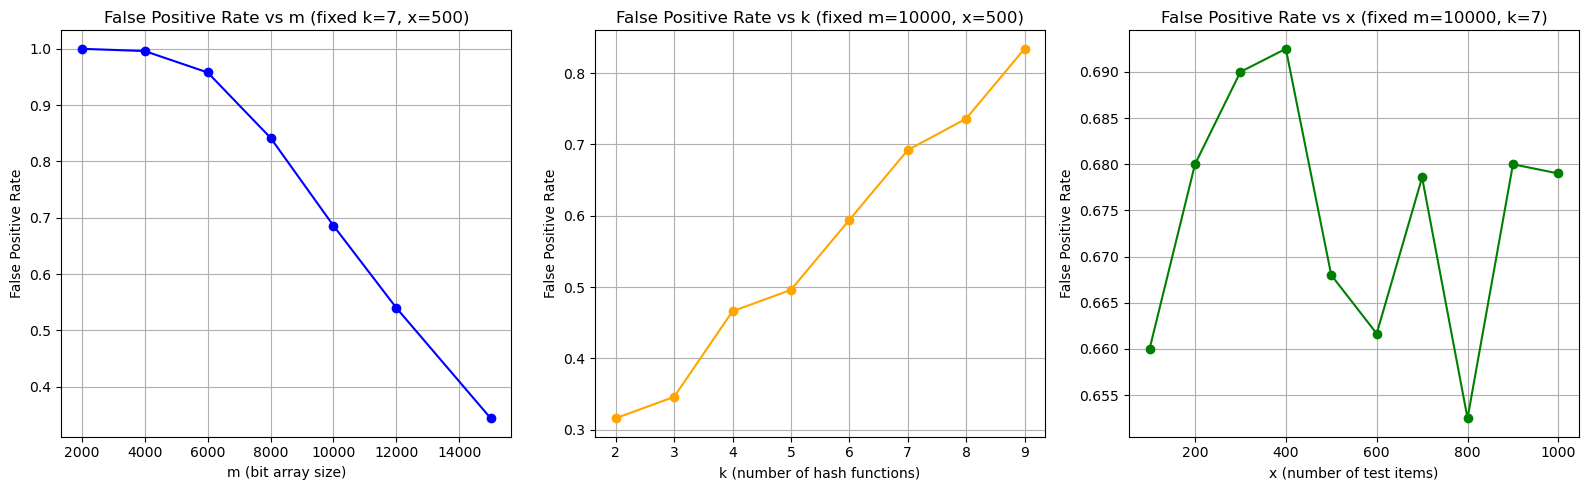

In [29]:
x_values = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Fixed parameters
fixed_m = 10000
fixed_k = 7
fixed_x = 500

# Experiment 1: Vary m
m_values = [2000, 4000, 6000, 8000, 10000, 12000, 15000]
fpr_m = []

for m in m_values:
    bf = BloomFilter(size=m, hashfuncCnt=fixed_k)
    for code in uniqueStkCodes:
        bf.addElement(code)
    
    # Generate non-present items, ensuring no overlap with uniqueStkCodes
    not_present = []
    while len(not_present) < fixed_x:
        fake_code = f"FAKE_{random.randint(0, 999999)}"
        if fake_code not in uniqueStkCodes:
            not_present.append(fake_code)
    
    false_positives = sum(bf.existCheck(x) for x in not_present)
    fpr = false_positives / fixed_x
    fpr_m.append(fpr)

# Experiment 2: Vary k
k_values = [2, 3, 4, 5, 6, 7, 8, 9]
fpr_k = []

for k in k_values:
    bf = BloomFilter(size=fixed_m, hashfuncCnt=k)
    for code in uniqueStkCodes:
        bf.addElement(code)
    
    not_present = []
    while len(not_present) < fixed_x:
        fake_code = f"FAKE_{random.randint(0, 999999)}"
        if fake_code not in uniqueStkCodes:
            not_present.append(fake_code)
    
    false_positives = sum(bf.existCheck(x) for x in not_present)
    fpr = false_positives / fixed_x
    fpr_k.append(fpr)

# Experiment 3: Vary x
fpr_x = []

for x in x_values:
    bf = BloomFilter(size=fixed_m, hashfuncCnt=fixed_k)
    for code in uniqueStkCodes:
        bf.addElement(code)
    
    not_present = []
    while len(not_present) < x:
        fake_code = f"FAKE_{random.randint(0, 999999)}"
        if fake_code not in uniqueStkCodes:
            not_present.append(fake_code)
    
    false_positives = sum(bf.existCheck(i) for i in not_present)
    fpr = false_positives / x
    fpr_x.append(fpr)

# Sensitivity Test
bf = BloomFilter(size=fixed_m, hashfuncCnt=fixed_k)
for code in uniqueStkCodes:
    bf.addElement(code)

for x in x_values:
    present = random.sample(uniqueStkCodes, min(x, len(uniqueStkCodes)))
    true_positives = sum(bf.existCheck(i) for i in present)
    sensitivity = true_positives / len(present)
    assert abs(sensitivity - 1.0) < 1e-6, f"Sensitivity check failed for x={x}!"
print("✅ Sensitivity = 1 confirmed for all x.")

# Plot Results with Matplotlib
plt.figure(figsize=(16, 5))

# Plot 1: FPR vs m
plt.subplot(1, 3, 1)
plt.plot(m_values, fpr_m, marker='o', color='blue')
plt.title("False Positive Rate vs m (fixed k=7, x=500)")
plt.xlabel("m (bit array size)")
plt.ylabel("False Positive Rate")
plt.grid(True)

# Plot 2: FPR vs k
plt.subplot(1, 3, 2)
plt.plot(k_values, fpr_k, marker='o', color='orange')
plt.title("False Positive Rate vs k (fixed m=10000, x=500)")
plt.xlabel("k (number of hash functions)")
plt.ylabel("False Positive Rate")
plt.grid(True)

# Plot 3: FPR vs x
plt.subplot(1, 3, 3)
plt.plot(x_values, fpr_x, marker='o', color='green')
plt.title("False Positive Rate vs x (fixed m=10000, k=7)")
plt.xlabel("x (number of test items)")
plt.ylabel("False Positive Rate")
plt.grid(True)

plt.tight_layout()
plt.show()


### Q2(b) Misra-Gries Algorithm

Frequency Estimation in a Data Stream

**Source:** `https://www.cs.dartmouth.edu/~ac/Teach/data-streams-lecnotes.pdf`

## Misra-Gries Algorithm Formulas

### 1. Stream and Frequency
- Let $S = \{ s_1, s_2, \dots, s_n \}$ be the stream of $n$ items (e.g., `StockCode` values).
- The **true frequency** of item $i$ is $f_i$:
  $$
  f_i = |\{ j : s_j = i \}|
  $$
  where $f_i$ is the number of times item $i$ appears in $S$.
- The **estimated frequency** from Misra-Gries is $\hat{f_i}$.


### 2. Misra-Gries Guarantee
- The algorithm guarantees to identify all items with frequency $f_i > \frac{n}{k}$.
- For each item $i$ in the output dictionary, the estimate $\hat{f_i}$ is bounded:
  $$
  f_i - \frac{n}{k} \leq \hat{f_i} \leq f_i
  $$
  where $\frac{n}{k}$ is the theoretical error bound on frequency estimates.


### 3. Precision
- **Precision** measures the fraction of items in the Misra-Gries output that are in the actual top-$k$ items:
  $$
  \text{Precision} = \frac{|\text{Misra-Gries items} \cap \text{Actual top-}k \text{ items}|}{|\text{Misra-Gries items}|}
  $$
  where:
  - $\text{Misra-Gries items} = \{ i : i \in \text{Misra-Gries output} \}$
  - $\text{Actual top-}k \text{ items}$ are the $k$ items with the highest true frequencies.


### 4. Maximum Frequency Error
- The **Maximum Error** in frequency estimates for items in the Misra-Gries output:
  $$
  \text{Max Error} = \max_{i \in \text{Misra-Gries items}} | f_i - \hat{f_i} |
  $$
- **Normalized max error** (for plotting):
  $$
  \frac{\text{Max Error}}{n}
  $$


### 5. Theoretical Error Bound
- The **theoretical upper bound** on frequency error:
  $$
  \text{Theoretical Bound} = \frac{n}{k}
  $$
- **Normalized theoretical bound**:
  $$
  \frac{\text{Theoretical Bound}}{n} = \frac{1}{k}
  $$



In [20]:
class DataStream:
    def __init__(self, thresh: int):
        if thresh <= 0:
            raise ValueError("Threshold must be positive")
        self.thresh = thresh
        self.freq_map = {}

    ## ACTUAL Misra-Gries Algorithm implementation
    def addElement(self, element):
        if element in self.freq_map.keys():
            self.freq_map[element] += 1
        else:
            self.freq_map[element] = 1
        if len(self.freq_map) >= self.thresh:
            keys_to_remove = []
            for key in self.freq_map.keys():
                self.freq_map[key] -= 1
                if self.freq_map[key] == 0:
                    keys_to_remove.append(key)
            for key in keys_to_remove:
                del self.freq_map[key]

    def queryEle(self, element):
        if element in self.freq_map.keys():
            return self.freq_map.get(element,0)
    
    def freqElereturn(self):
        return self.freq_map
        


In [24]:
dataframe = pd.read_csv('online-retail.csv')
stockCodes = dataframe['StockCode']
direct_freq_map = {}
for code in stockCodes:
    if code in direct_freq_map:
        direct_freq_map[code] += 1
    else:
        direct_freq_map[code] = 1

print("Direct frequency count of elements:")
print(len(direct_freq_map))
n = len(stockCodes)
print(f"Total items in stream: {n}")
print(f"Unique StockCodes: {len(direct_freq_map)}")


Direct frequency count of elements:
4070
Total items in stream: 541909
Unique StockCodes: 4070


In [25]:
def get_actual_top_k(direct_freq_map, k):
    sorted_items = sorted(direct_freq_map.items(), key=lambda x: x[1], reverse=True)
    return sorted_items[:k]

# Function to compute Misra-Gries frequent items
def run_misra_gries(stockCodes, k):
    ds = DataStream(k)
    for code in stockCodes:
        ds.addElement(code)
    return ds.freqElereturn()

# Function to compare Misra-Gries output with actual top-k
def compare_results(misra_gries_freq, actual_top_k, n, k):
    misra_items = set(misra_gries_freq.keys())
    actual_items = set(item[0] for item in actual_top_k)
    
    # True positives: items in both Misra-Gries and actual top-k
    true_positives = misra_items.intersection(actual_items)
    precision = len(true_positives) / len(misra_items) if misra_items else 0
    
    # Error analysis: compute max error in frequency estimates
    max_error = 0
    for item in misra_items:
        true_freq = direct_freq_map.get(item, 0)
        est_freq = misra_gries_freq.get(item, 0)
        error = abs(true_freq - est_freq)
        if error > max_error:
            max_error = error
    
    theoretical_error_bound = n / k
    return precision, max_error, theoretical_error_bound


Results for k=10:
Precision: 0.0000
Max frequency error: 973
Theoretical error bound: 54190.9
Misra-Gries items (top 5): [('22730', 1), ('22367', 1), ('22629', 1), ('23256', 1), ('22613', 1)]
Actual top-10 items (top 5): [('85123A', 2313), ('22423', 2203), ('85099B', 2159), ('47566', 1727), ('20725', 1639)]

Results for k=50:
Precision: 0.3333
Max frequency error: 1106
Theoretical error bound: 10838.18
Misra-Gries items (top 5): [('85038', 1), ('22726', 1), ('22727', 1), ('23256', 1), ('22613', 1)]
Actual top-50 items (top 5): [('85123A', 2313), ('22423', 2203), ('85099B', 2159), ('47566', 1727), ('20725', 1639)]

Results for k=100:
Precision: 0.5556
Max frequency error: 1255
Theoretical error bound: 5419.09
Misra-Gries items (top 5): [('POST', 1), ('23084', 1), ('85038', 1), ('22726', 1), ('22727', 1)]
Actual top-100 items (top 5): [('85123A', 2313), ('22423', 2203), ('85099B', 2159), ('47566', 1727), ('20725', 1639)]

Results for k=200:
Precision: 0.3253
Max frequency error: 1638
Th

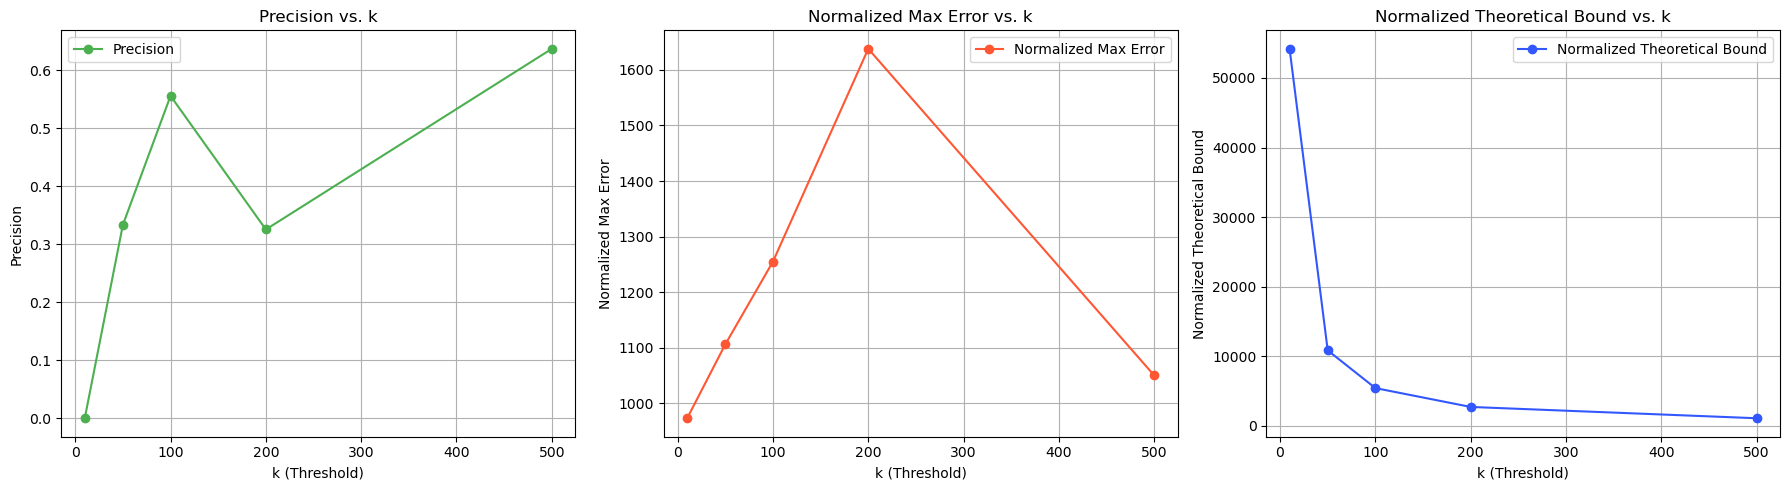

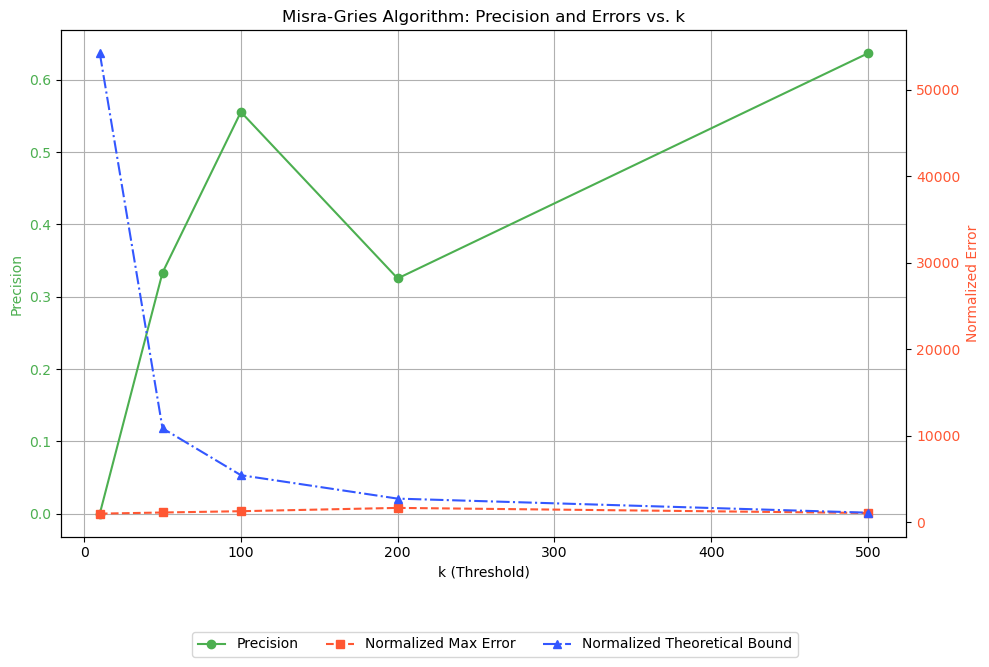

In [28]:
k_values = [10, 50, 100, 200, 500]
precisions = []
max_errors = []
theoretical_bounds = []

for k in k_values:
    # Run Misra-Gries
    misra_gries_freq = run_misra_gries(stockCodes, k)
    # Get actual top-k
    actual_top_k = get_actual_top_k(direct_freq_map, k)
    # Compare results
    precision, max_error, theoretical_bound = compare_results(misra_gries_freq, actual_top_k, n, k)
    precisions.append(precision)
    max_errors.append(max_error)
    theoretical_bounds.append(theoretical_bound)
    
    print(f"\nResults for k={k}:")
    print(f"Precision: {precision:.4f}")
    print(f"Max frequency error: {max_error}")
    print(f"Theoretical error bound: {theoretical_bound}")
    print(f"Misra-Gries items (top 5): {list(misra_gries_freq.items())[:5]}")
    print(f"Actual top-{k} items (top 5): {actual_top_k[:5]}")


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Precision vs. k
ax1.plot(k_values, precisions, marker='o', linestyle='-', color='#4CAF50', label='Precision')
ax1.set_xlabel('k (Threshold)')
ax1.set_ylabel('Precision')
ax1.set_title('Precision vs. k')
ax1.grid(True)
ax1.legend()

# Plot 2: Normalized Max Frequency Error vs. k
ax2.plot(k_values, max_errors, marker='o', linestyle='-', color='#FF5733', label='Normalized Max Error')
ax2.set_xlabel('k (Threshold)')
ax2.set_ylabel('Normalized Max Error')
ax2.set_title('Normalized Max Error vs. k')
ax2.grid(True)
ax2.legend()

# Plot 3: Normalized Theoretical Error Bound vs. k
ax3.plot(k_values, theoretical_bounds, marker='o', linestyle='-', color='#3357FF', label='Normalized Theoretical Bound')
ax3.set_xlabel('k (Threshold)')
ax3.set_ylabel('Normalized Theoretical Bound')
ax3.set_title('Normalized Theoretical Bound vs. k')
ax3.grid(True)
ax3.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Plot 4: Combined Plot with Dual Y-Axis (below the subplots)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot precision on primary y-axis
ax1.plot(k_values, precisions, marker='o', linestyle='-', color='#4CAF50', label='Precision')
ax1.set_xlabel('k (Threshold)')
ax1.set_ylabel('Precision', color='#4CAF50')
ax1.tick_params(axis='y', labelcolor='#4CAF50')
ax1.grid(True)

# Create secondary y-axis for errors
ax2 = ax1.twinx()
ax2.plot(k_values, max_errors, marker='s', linestyle='--', color='#FF5733', label='Normalized Max Error')
ax2.plot(k_values, theoretical_bounds, marker='^', linestyle='-.', color='#3357FF', label='Normalized Theoretical Bound')
ax2.set_ylabel('Normalized Error', color='#FF5733')
ax2.tick_params(axis='y', labelcolor='#FF5733')

# Title and legend
plt.title('Misra-Gries Algorithm: Precision and Errors vs. k')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.tight_layout()
plt.show()

# Question 3

In [26]:
# a)
from sklearn.datasets import fetch_kddcup99
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
def ToInt(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal

def cost(D, C):
    cost = 0
    for i in range(D.shape[0]):
        dist = np.linalg.norm(D[i] - C, axis=1)
        cost += min(dist)**2
    return cost

In [28]:
dataset = fetch_kddcup99(subset=None)
N = dataset.data.shape[0]
D = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
print(df_normal)

DATA = df_normal.to_numpy()
DATA.shape

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\2290841944.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


        0   1   2   3    4     5   6   7   8   9   ...  31   32     33   34  \
0        0   1  22   9  164  4773   0   0   0   0  ...   9    9  100.0  0.0   
1        0   1  22   9  222   465   0   0   0   0  ...  19   19  100.0  0.0   
2        0   1  22   9  218  1316   0   0   0   0  ...  29   29  100.0  0.0   
3        0   1  22   9  202  1316   0   0   0   0  ...  39   39  100.0  0.0   
4        0   1  22   9  200  2006   0   0   0   0  ...  49   49  100.0  0.0   
...     ..  ..  ..  ..  ...   ...  ..  ..  ..  ..  ...  ..  ...    ...  ...   
494016   0   1  22   9  293  1856   0   0   0   0  ...  86  255  100.0  0.0   
494017   0   1  22   9  265  2254   0   0   0   0  ...   6  255  100.0  0.0   
494018   0   1  22   9  186  1179   0   0   0   0  ...  16  255  100.0  0.0   
494019   0   1  22   9  274  1179   0   0   0   0  ...  26  255  100.0  0.0   
494020   0   1  22   9  202  1213   0   0   0   0  ...   6  255  100.0  0.0   

           35   36   37    38   39   40  
0        

(494021, 41)

In [ ]:
costs = []

for X in [5, 10, 15, 20, 25]:
    costs.extend([[]])
    for i in range(5):
        M = np.random.normal(0, 1/np.sqrt(X), size=(D, X))
        E = DATA @ M
        
        kE = KMeans(n_clusters=15)
        kE.fit(E)
        A = kE.cluster_centers_
        
        kDATA = KMeans(n_clusters=15)
        kDATA.fit(DATA)
        B = kDATA.cluster_centers_
        
        CostA = cost(DATA, A @ np.linalg.pinv(M))
        CostB = cost(DATA, B)
        costs[-1].append((CostA, CostB))

for i in range(len(costs)):
    for j in range(5):
        print(f'x = {(i+1)*5} Cost(A) : {costs[i][j][0]}, Cost(B) : {costs[i][j][1]}')

x = 5 Cost(A) : 1237586216305.2073 Cost(B) : 16656122730.422739
x = 5 Cost(A) : 1261275346901.6462 Cost(B) : 17112427980.779793
x = 5 Cost(A) : 1414012970888.2324 Cost(B) : 19795979474.90592
x = 5 Cost(A) : 1400427934253.8083 Cost(B) : 19561894800.086708
x = 5 Cost(A) : 1191129883782.7275 Cost(B) : 17274792568.39173
x = 10 Cost(A) : 1091219740171.9365 Cost(B) : 18010341086.165962
x = 10 Cost(A) : 897156199935.0723 Cost(B) : 16648756217.917751
x = 10 Cost(A) : 1086016828605.5522 Cost(B) : 17112398721.908554
x = 10 Cost(A) : 1016490261942.5363 Cost(B) : 19281284479.14198
x = 10 Cost(A) : 1066396222412.7312 Cost(B) : 16648710362.218502
x = 15 Cost(A) : 899285045633.5101 Cost(B) : 17112421118.328897
x = 15 Cost(A) : 878187551217.1042 Cost(B) : 16656102286.830769
x = 15 Cost(A) : 1072746737334.0848 Cost(B) : 17854568215.488052
x = 15 Cost(A) : 706528185519.0236 Cost(B) : 16590039803.721498
x = 15 Cost(A) : 758922948206.0131 Cost(B) : 17997728421.89691
x = 20 Cost(A) : 810817658218.8223 Cost

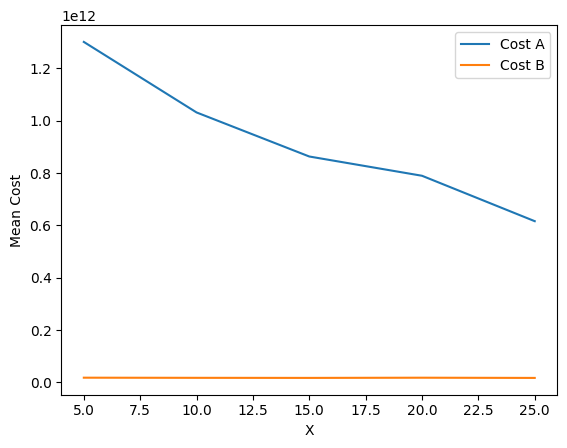

In [30]:
mean_costs_A = [np.mean([i[0] for i in cc]) for cc in costs]
mean_costs_B = [np.mean([i[1] for i in cc]) for cc in costs]
plt.plot([5, 10, 15, 20, 25], mean_costs_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], mean_costs_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()

In [ ]:
# b)
from sklearn.datasets import fetch_kddcup99
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [32]:
def ToInt(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal

def Losses(D, Y, C):
    loss = 0
    for i in range(D.shape[0]):
        pred = D[i] @ C.T
        loss += (pred - Y[i])**2
    return loss

In [33]:
dataset = fetch_kddcup99(subset=None)
N = dataset.data.shape[0]
D = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
print(df_normal)

DATA = df_normal.to_numpy()
DATA.shape

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\679658869.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


        0   1   2   3    4     5   6   7   8   9   ...  31   32     33   34  \
0        0   1  22   9  164  4773   0   0   0   0  ...   9    9  100.0  0.0   
1        0   1  22   9  222   465   0   0   0   0  ...  19   19  100.0  0.0   
2        0   1  22   9  218  1316   0   0   0   0  ...  29   29  100.0  0.0   
3        0   1  22   9  202  1316   0   0   0   0  ...  39   39  100.0  0.0   
4        0   1  22   9  200  2006   0   0   0   0  ...  49   49  100.0  0.0   
...     ..  ..  ..  ..  ...   ...  ..  ..  ..  ..  ...  ..  ...    ...  ...   
494016   0   1  22   9  293  1856   0   0   0   0  ...  86  255  100.0  0.0   
494017   0   1  22   9  265  2254   0   0   0   0  ...   6  255  100.0  0.0   
494018   0   1  22   9  186  1179   0   0   0   0  ...  16  255  100.0  0.0   
494019   0   1  22   9  274  1179   0   0   0   0  ...  26  255  100.0  0.0   
494020   0   1  22   9  202  1213   0   0   0   0  ...   6  255  100.0  0.0   

           35   36   37    38   39   40  
0        

(494021, 41)

In [34]:
Y = dataset.target
YLABEL = ToInt(pd.DataFrame(Y)).to_numpy()

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\679658869.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


In [35]:
loss = []
# takes a lot of time, need to optimize
for X in [25, 50, 100, 200, 500]:
    loss.extend([[]])
    for j in tqdm(range(5)):
        s = 3
        M = np.zeros((X, N))
        for i in range(X):
            for j in range(N):
                r = np.random.rand()
                if r < 1/(2*s):
                    M[i, j] = np.sqrt(s)
                elif r < 1 - 1/(2*s):
                    M[i, j] = 0
                else:
                    M[i, j] = -np.sqrt(s)
        E = M @ DATA
        Z = M @ YLABEL
        
        lE = LinearRegression()
        lE.fit(E, Z)
        A = lE.coef_
    
        lDATA = LinearRegression()
        lDATA.fit(DATA, YLABEL)
        B = lDATA.coef_
        
        LossA = Losses(DATA, YLABEL, A)
        LossB = Losses(DATA, YLABEL, B)
        loss[-1].append((LossA, LossB))

for i in range(len(loss)):
    for j in range(5):
        print(f'x = {(i+1)*5} Loss(A) : {loss[i][j][0]}, Loss(B) : {loss[i][j][1]}')

x = 5 Loss(A) : [1196373.49916351], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [20483381.0675026], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [7736033.02948709], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [14229910.51264676], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [11012120.23675692], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1138776.59588534], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1761686.51744057], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1674316.124131], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1670079.26533165], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1069758.81501531], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [714256.36383399], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [533636.15252417], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [505206.55828583], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [573886.70993473], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [461072.93815969], Loss(B) : [30559346.87276405]
x = 2

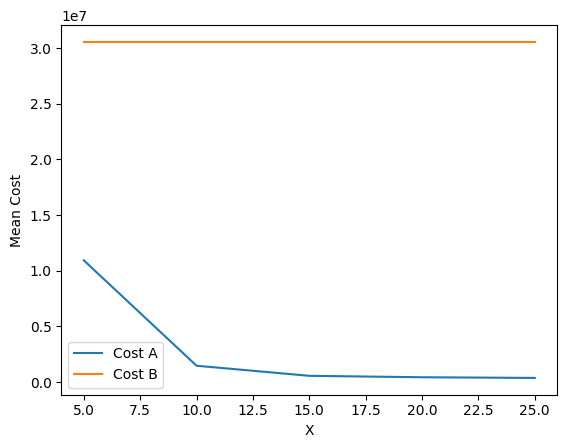

In [36]:
m_loss_A = [np.mean([i[0] for i in ll]) for ll in loss]
m_loss_B = [np.mean([i[1] for i in ll]) for ll in loss]
plt.plot([5, 10, 15, 20, 25], m_loss_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], m_loss_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()